In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV


In [2]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

def save_plot(filename):
    plt.savefig(f"{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    print(f"saved {filename}.eps")

# class names for fashion mnist (given in the dataset docs)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
#loading MNIST dataset directly from keras datasets
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print("Training data shape:", X_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)
print("Testing data shape:", X_test_raw.shape)
print("Testing labels shape:", y_test_raw.shape)


Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


saved sample_images.eps


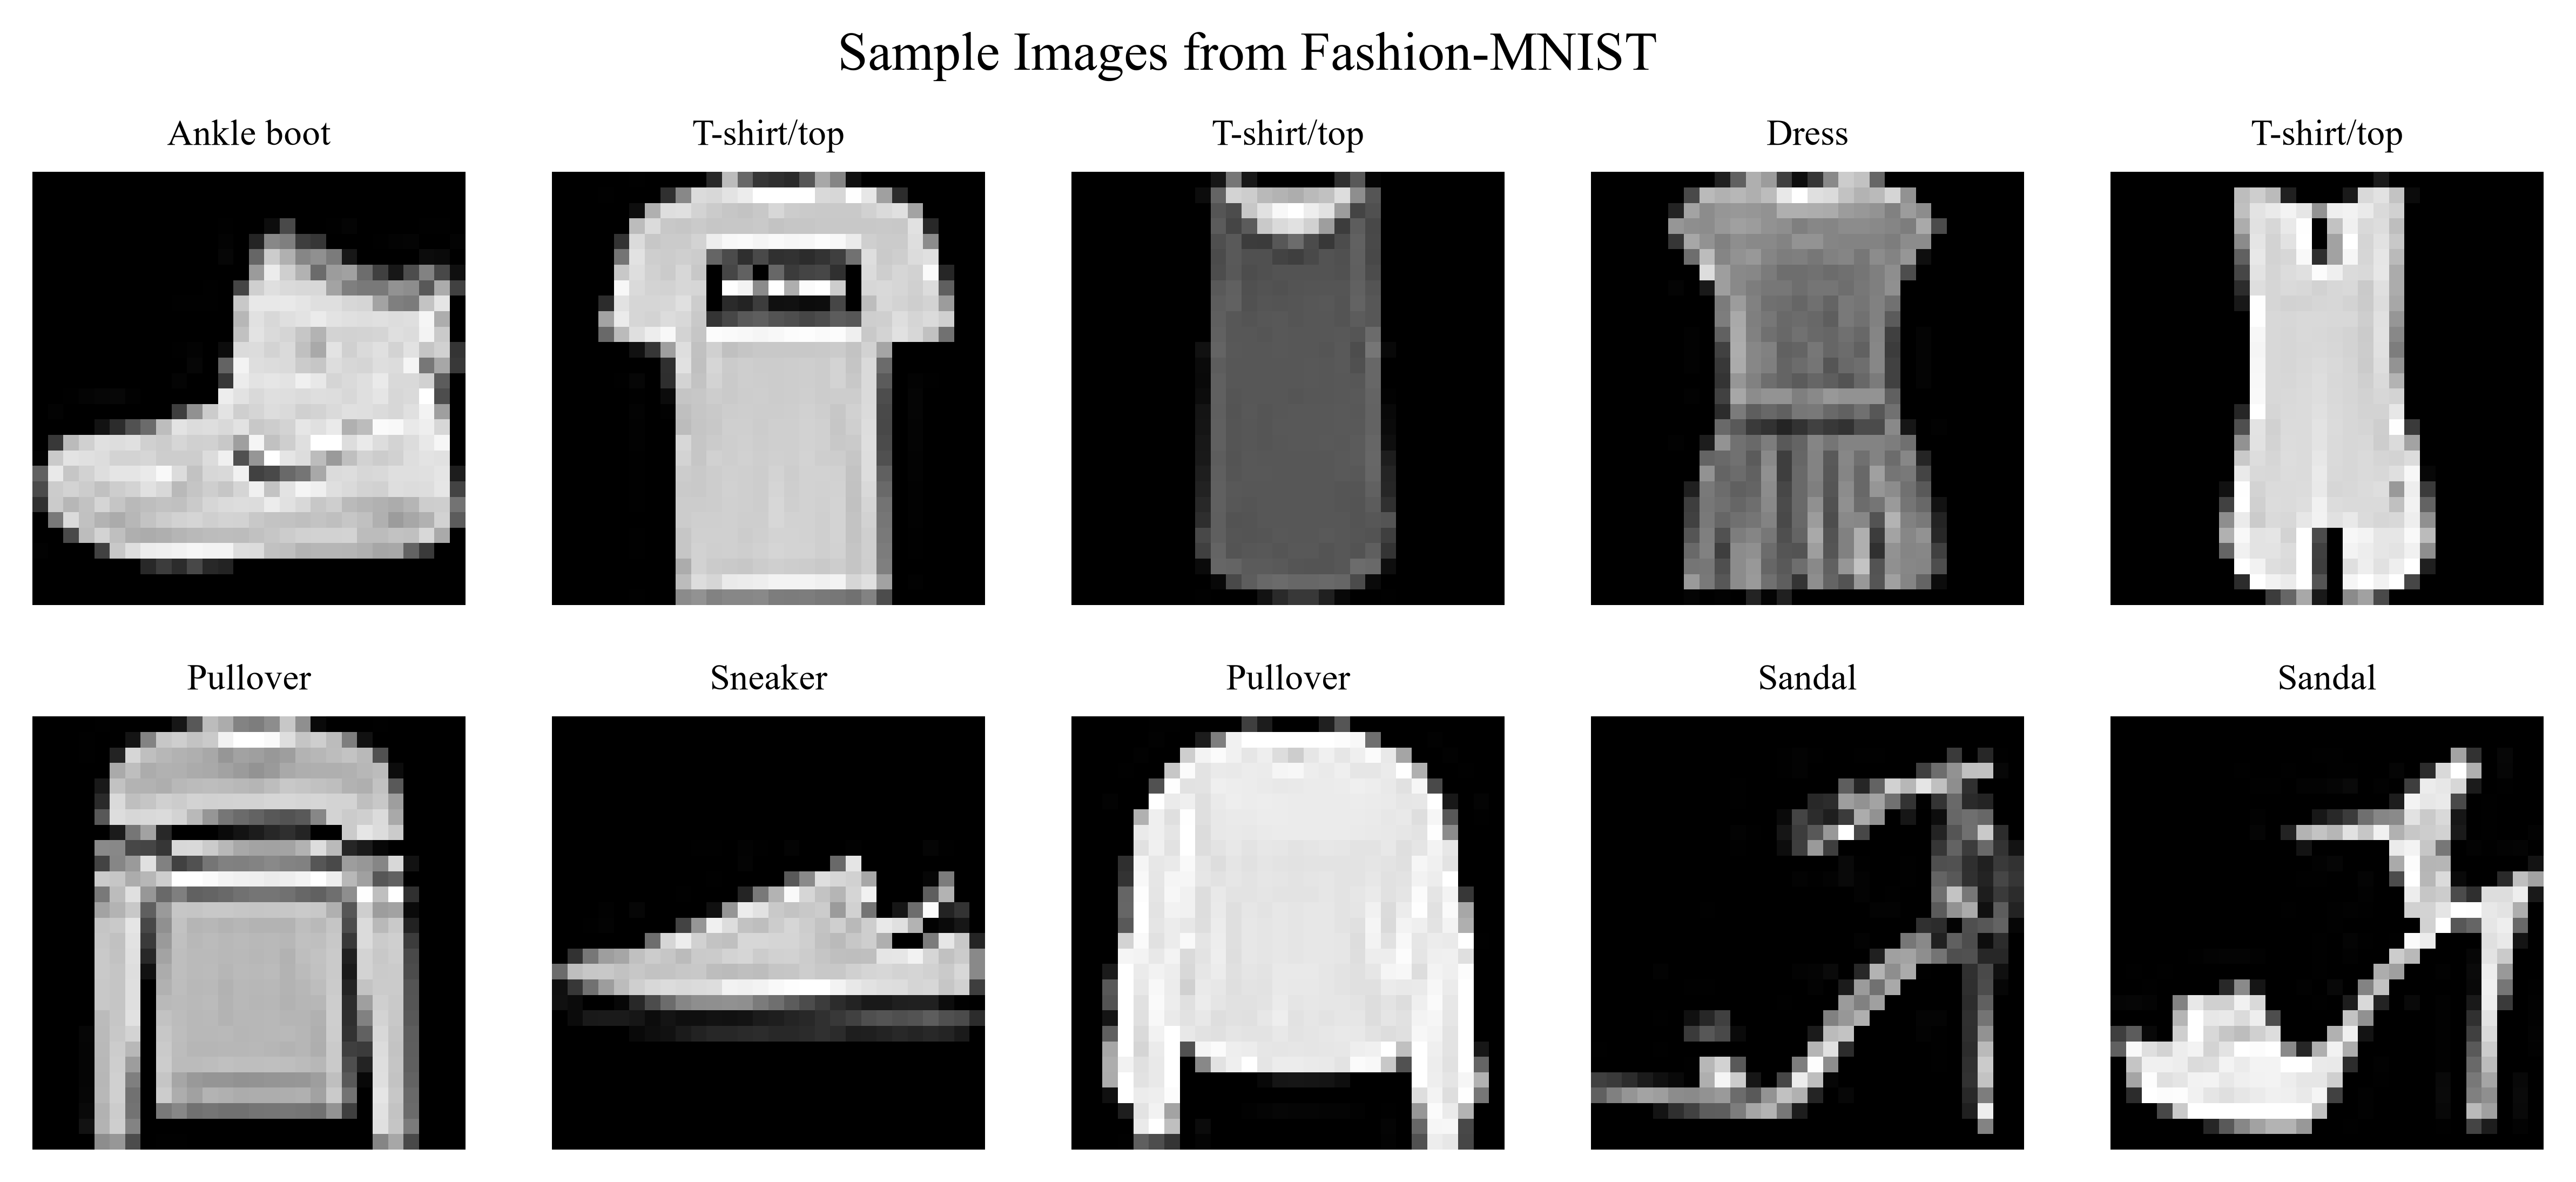

In [4]:
# displaying 10 sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(class_names[y_train_raw[i]], fontsize=8)
    plt.axis('off')
plt.suptitle("Sample Images from Fashion-MNIST")
save_plot("sample_images")
plt.show()

# Inference: the dataset contains grayscale images of clothing items like
# shirts, trousers, shoes etc, each labelled with its corresponding class.


saved class_distribution.eps


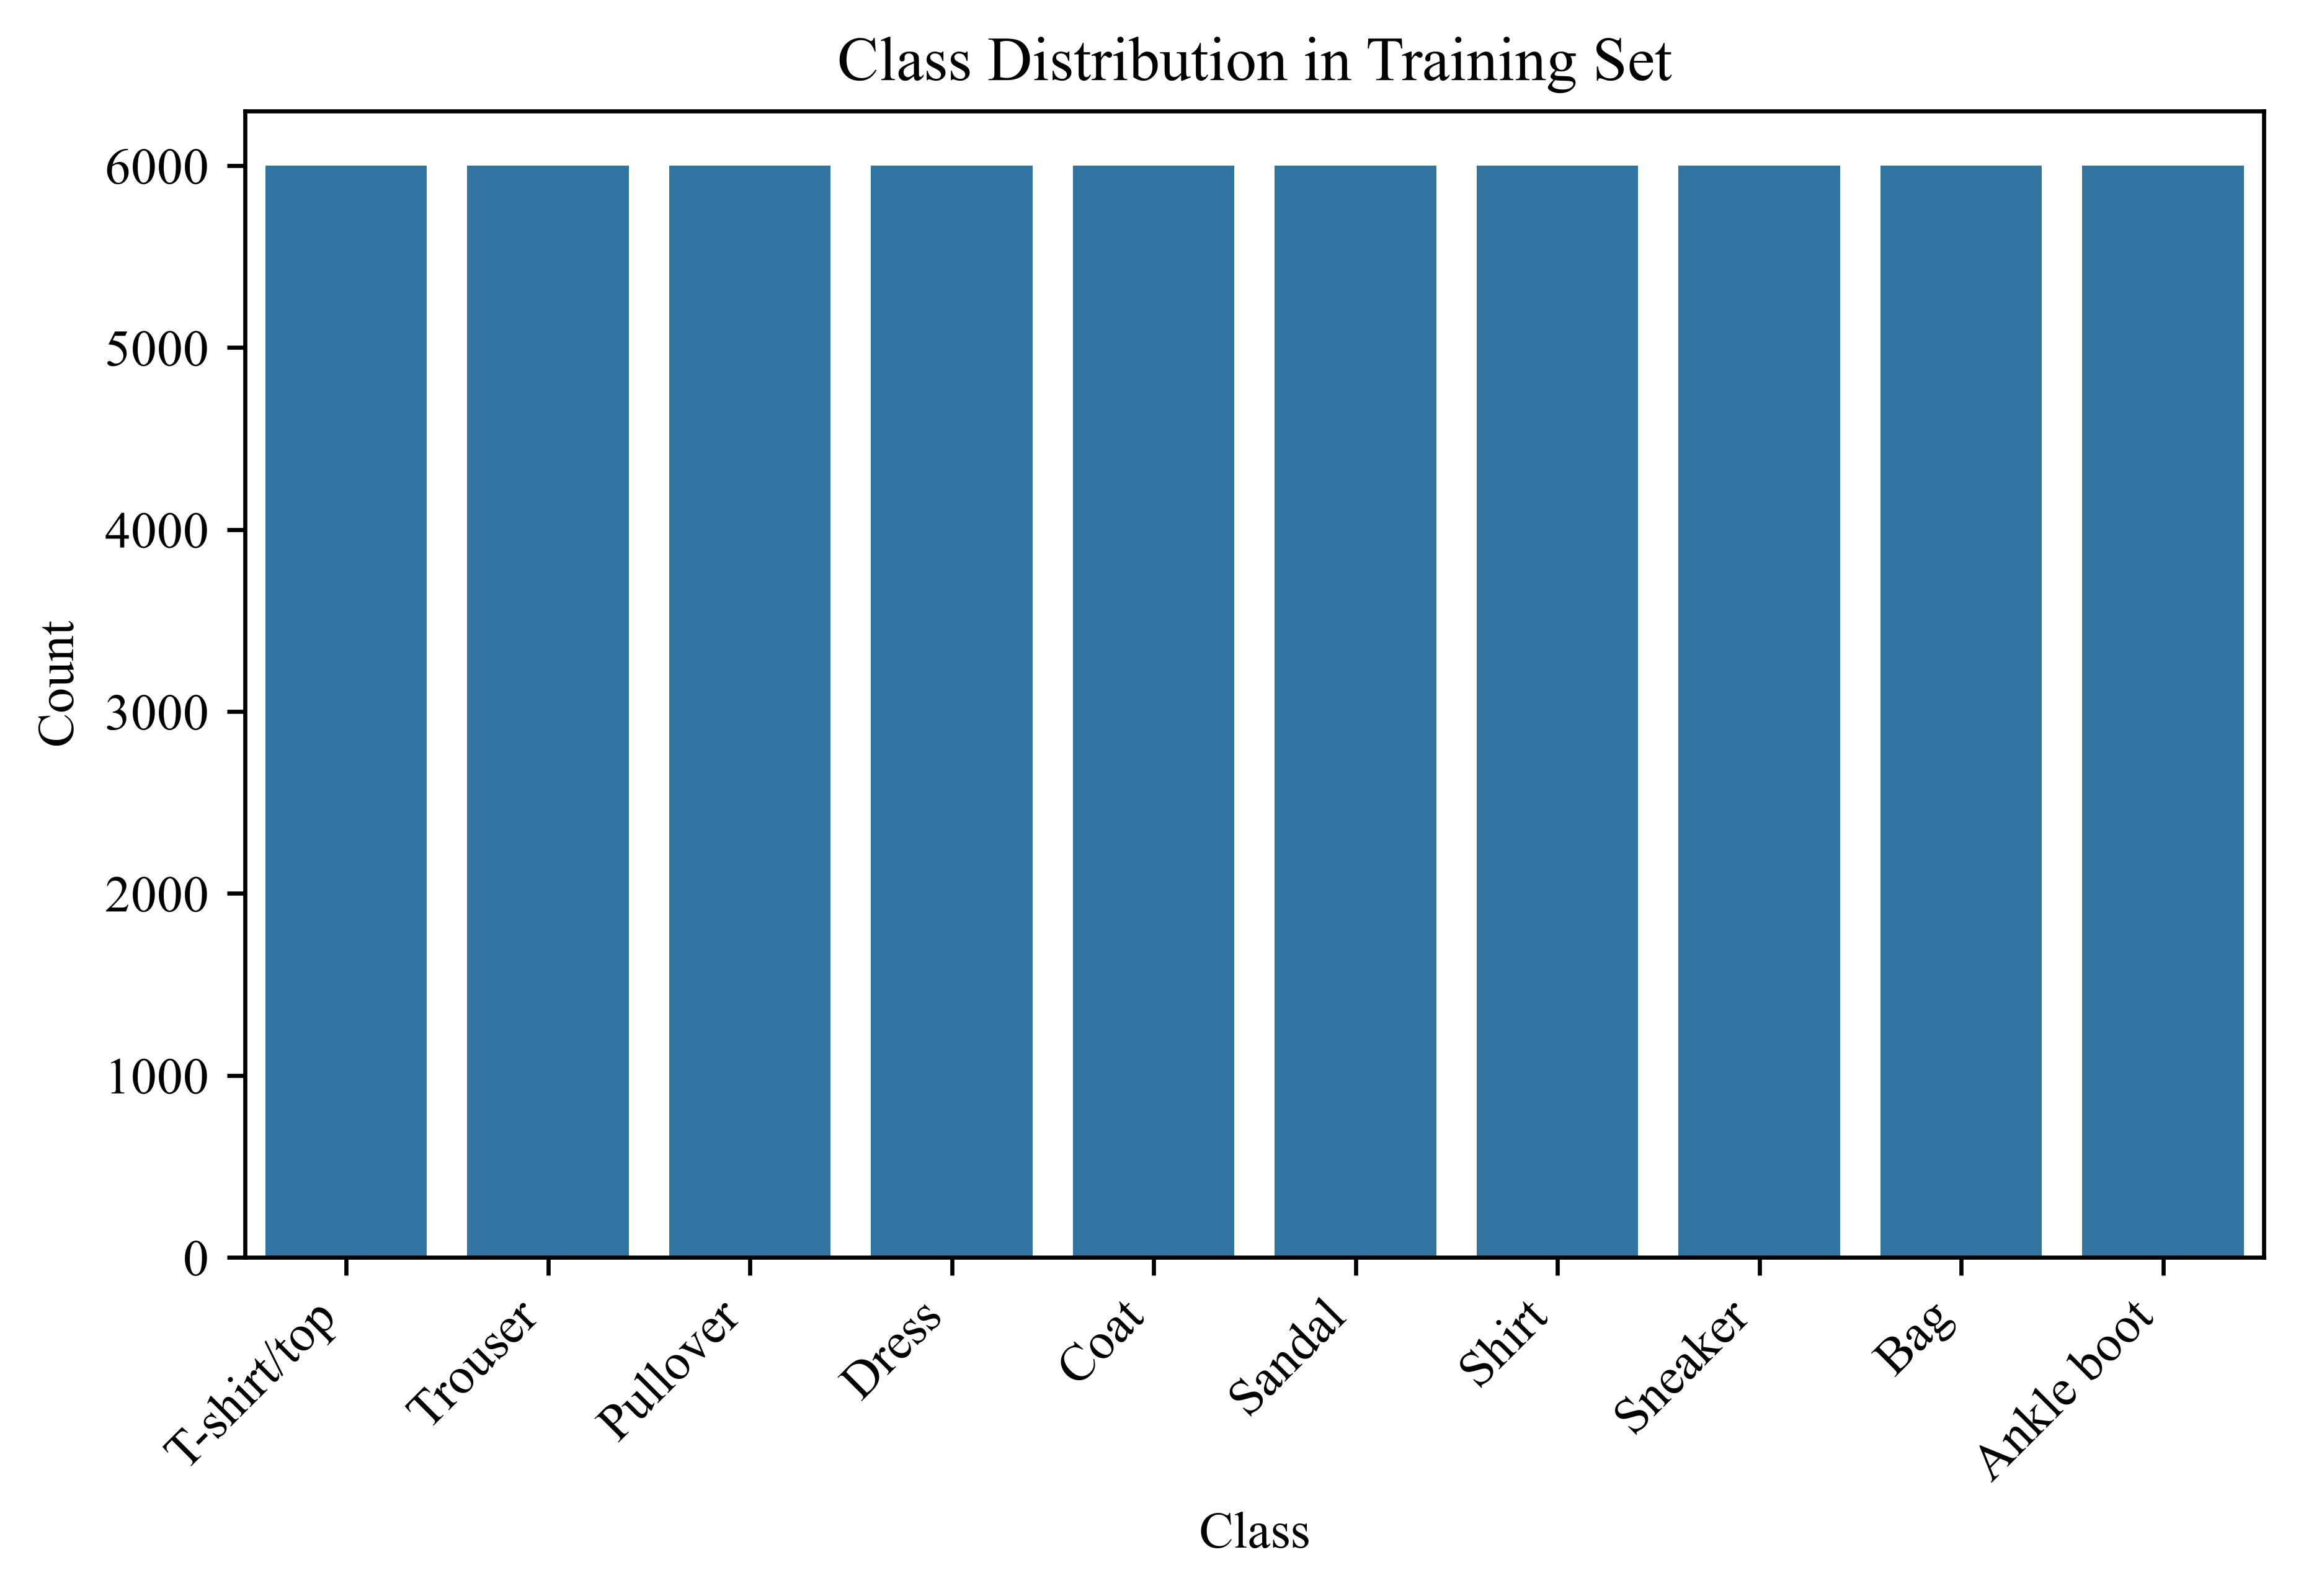

In [5]:
# class distribution plot
plt.figure(figsize=(7, 4))
sns.countplot(x=y_train_raw)
plt.xticks(ticks=range(10), labels=class_names, rotation=45, ha='right')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution in Training Set")
save_plot("class_distribution")
plt.show()

# Inference: all 10 classes have equal number of samples (6000 each),
# so the dataset is perfectly balanced and we dont need to worry about class imbalance.


In [6]:
print("Shape before preprocessing:", X_train_raw.shape)

# flattening 28x28 images into 784 length vectors
X_train = X_train_raw.reshape(X_train_raw.shape[0], 28*28)
X_test = X_test_raw.reshape(X_test_raw.shape[0], 28*28)

# normalizing pixel values to [0,1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Shape after preprocessing:", X_train.shape)

Shape before preprocessing: (60000, 28, 28)
Shape after preprocessing: (60000, 784)


In [7]:
# one hot encoding the labels
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("y_train shape after one-hot encoding:", y_train.shape)

y_train shape after one-hot encoding: (60000, 10)


In [8]:
# model construction
baseline_model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.summary()


c:\Users\Kishore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

start_time = time.time()

history = baseline_model.fit(X_train, y_train,
                              validation_split=0.1,
                              epochs=20,
                              batch_size=32,
                              verbose=1)

baseline_train_time = time.time() - start_time
print("Baseline training time (sec):", baseline_train_time)


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8216 - loss: 0.5017 - val_accuracy: 0.8502 - val_loss: 0.4025
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8642 - loss: 0.3713 - val_accuracy: 0.8587 - val_loss: 0.3906
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8787 - loss: 0.3343 - val_accuracy: 0.8682 - val_loss: 0.3658
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8851 - loss: 0.3110 - val_accuracy: 0.8725 - val_loss: 0.3445
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8914 - loss: 0.2934 - val_accuracy: 0.8790 - val_loss: 0.3305
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8945 - loss: 0.2799 - val_accuracy: 0.8825 - val_loss: 0.3294
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8998 - loss: 0.2673 - val_accuracy: 0.8822 - val_loss: 0.3302
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9037 - loss: 0.2560 - 

saved training_accuracy_vs_epoch.eps


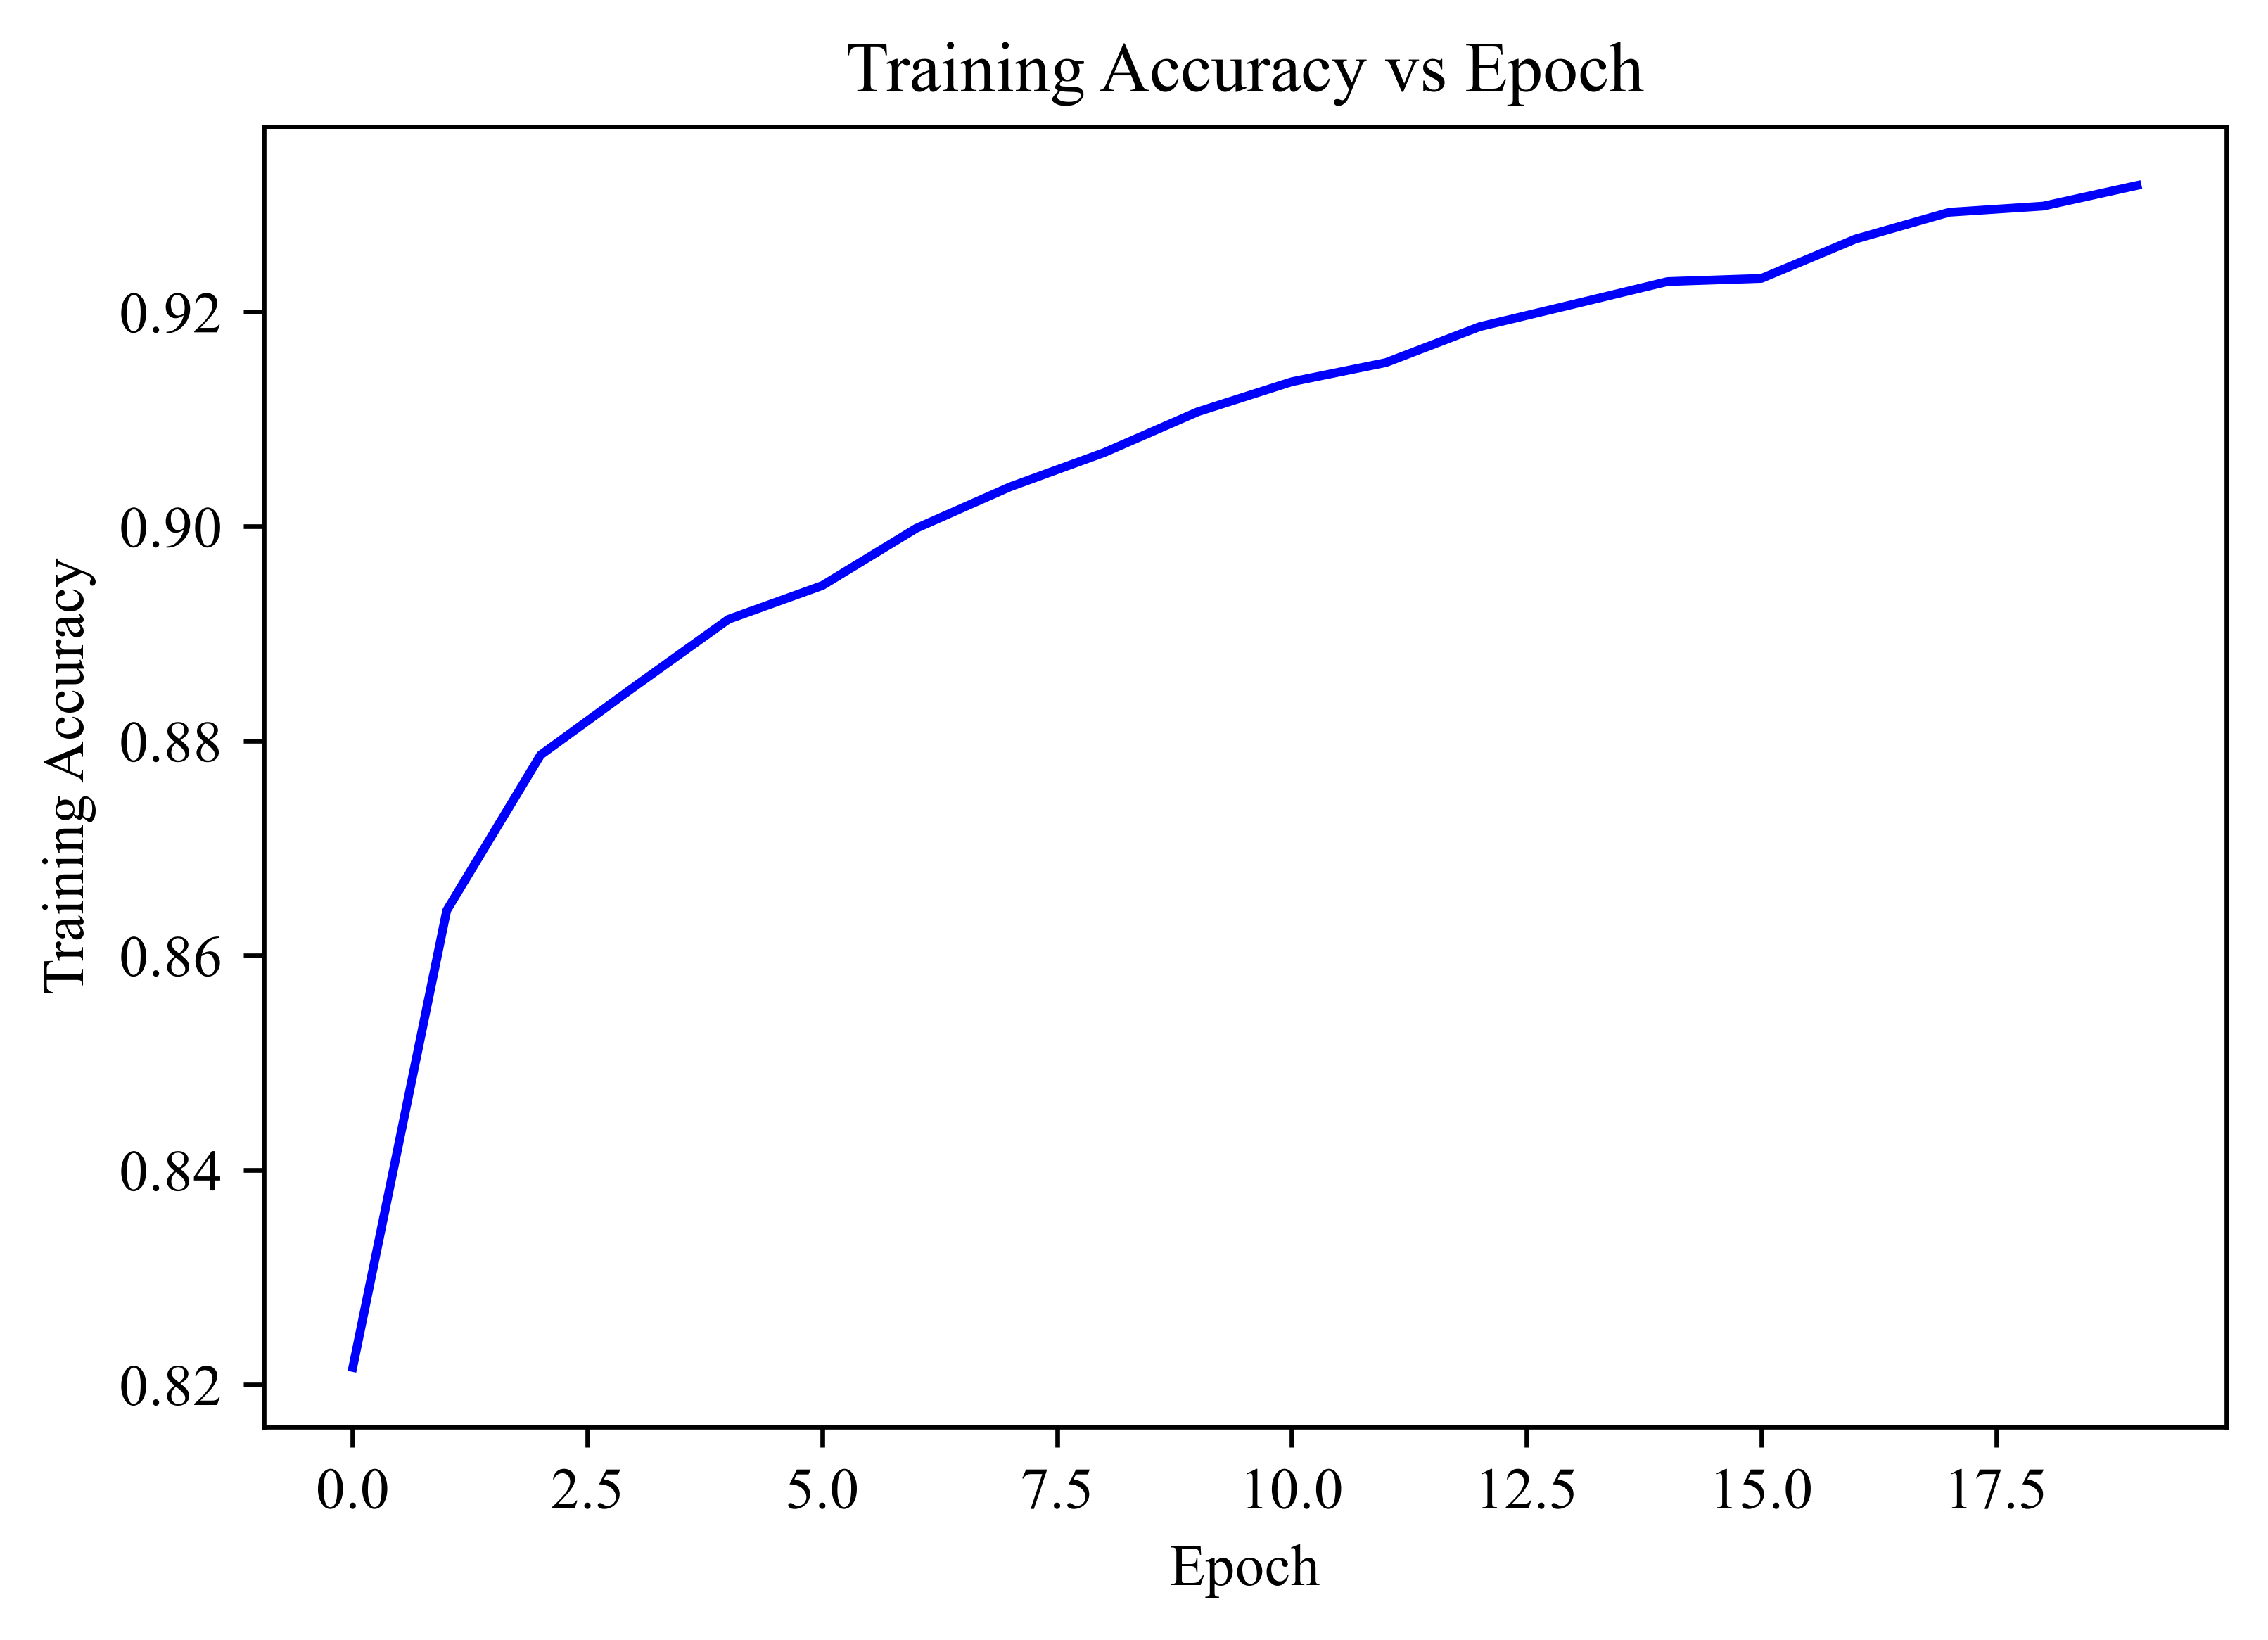

In [10]:
# training accuracy vs epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], color='blue')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epoch")
save_plot("training_accuracy_vs_epoch")
plt.show()

# Inference: training accuracy keeps increasing steadily with epochs,
# showing that the model is learning the patterns in the training data well.


saved validation_accuracy_vs_epoch.eps


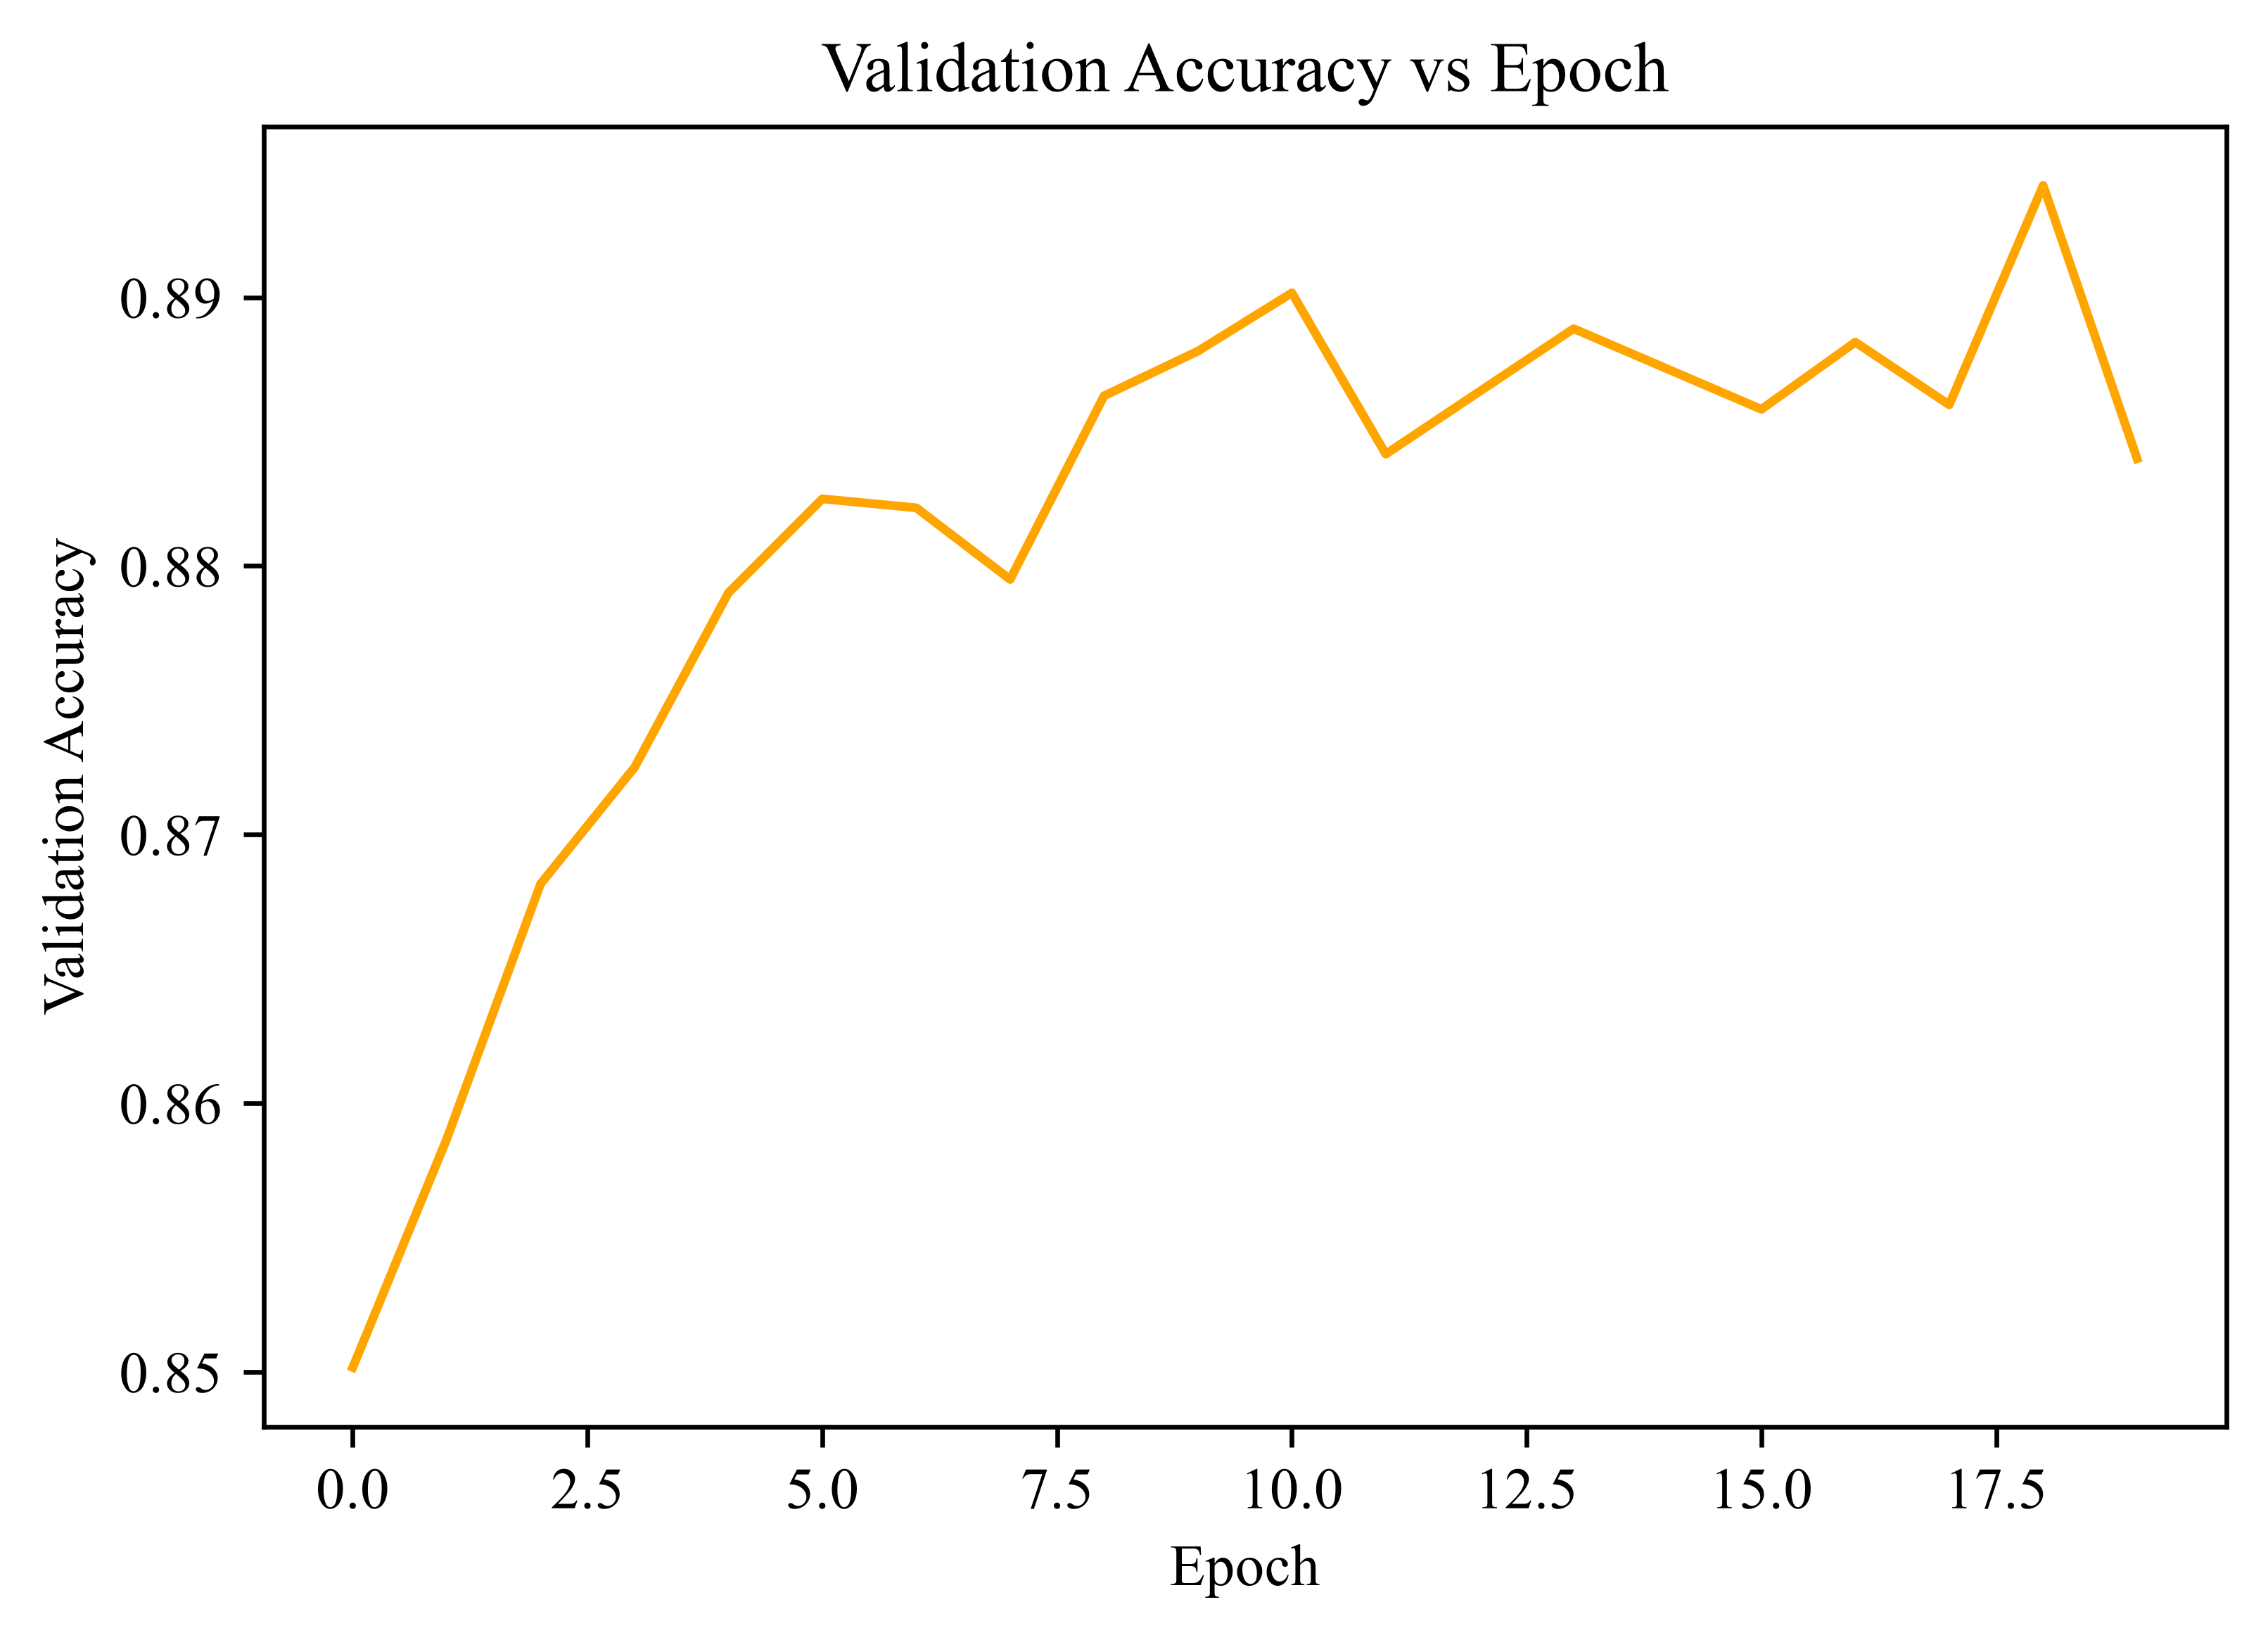

In [11]:
# validation accuracy vs epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], color='orange')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
save_plot("validation_accuracy_vs_epoch")
plt.show()

# Inference: validation accuracy also increases but flattens out after
# a certain point, indicating the model is close to its best performance on unseen data.

saved training_loss_vs_epoch.eps


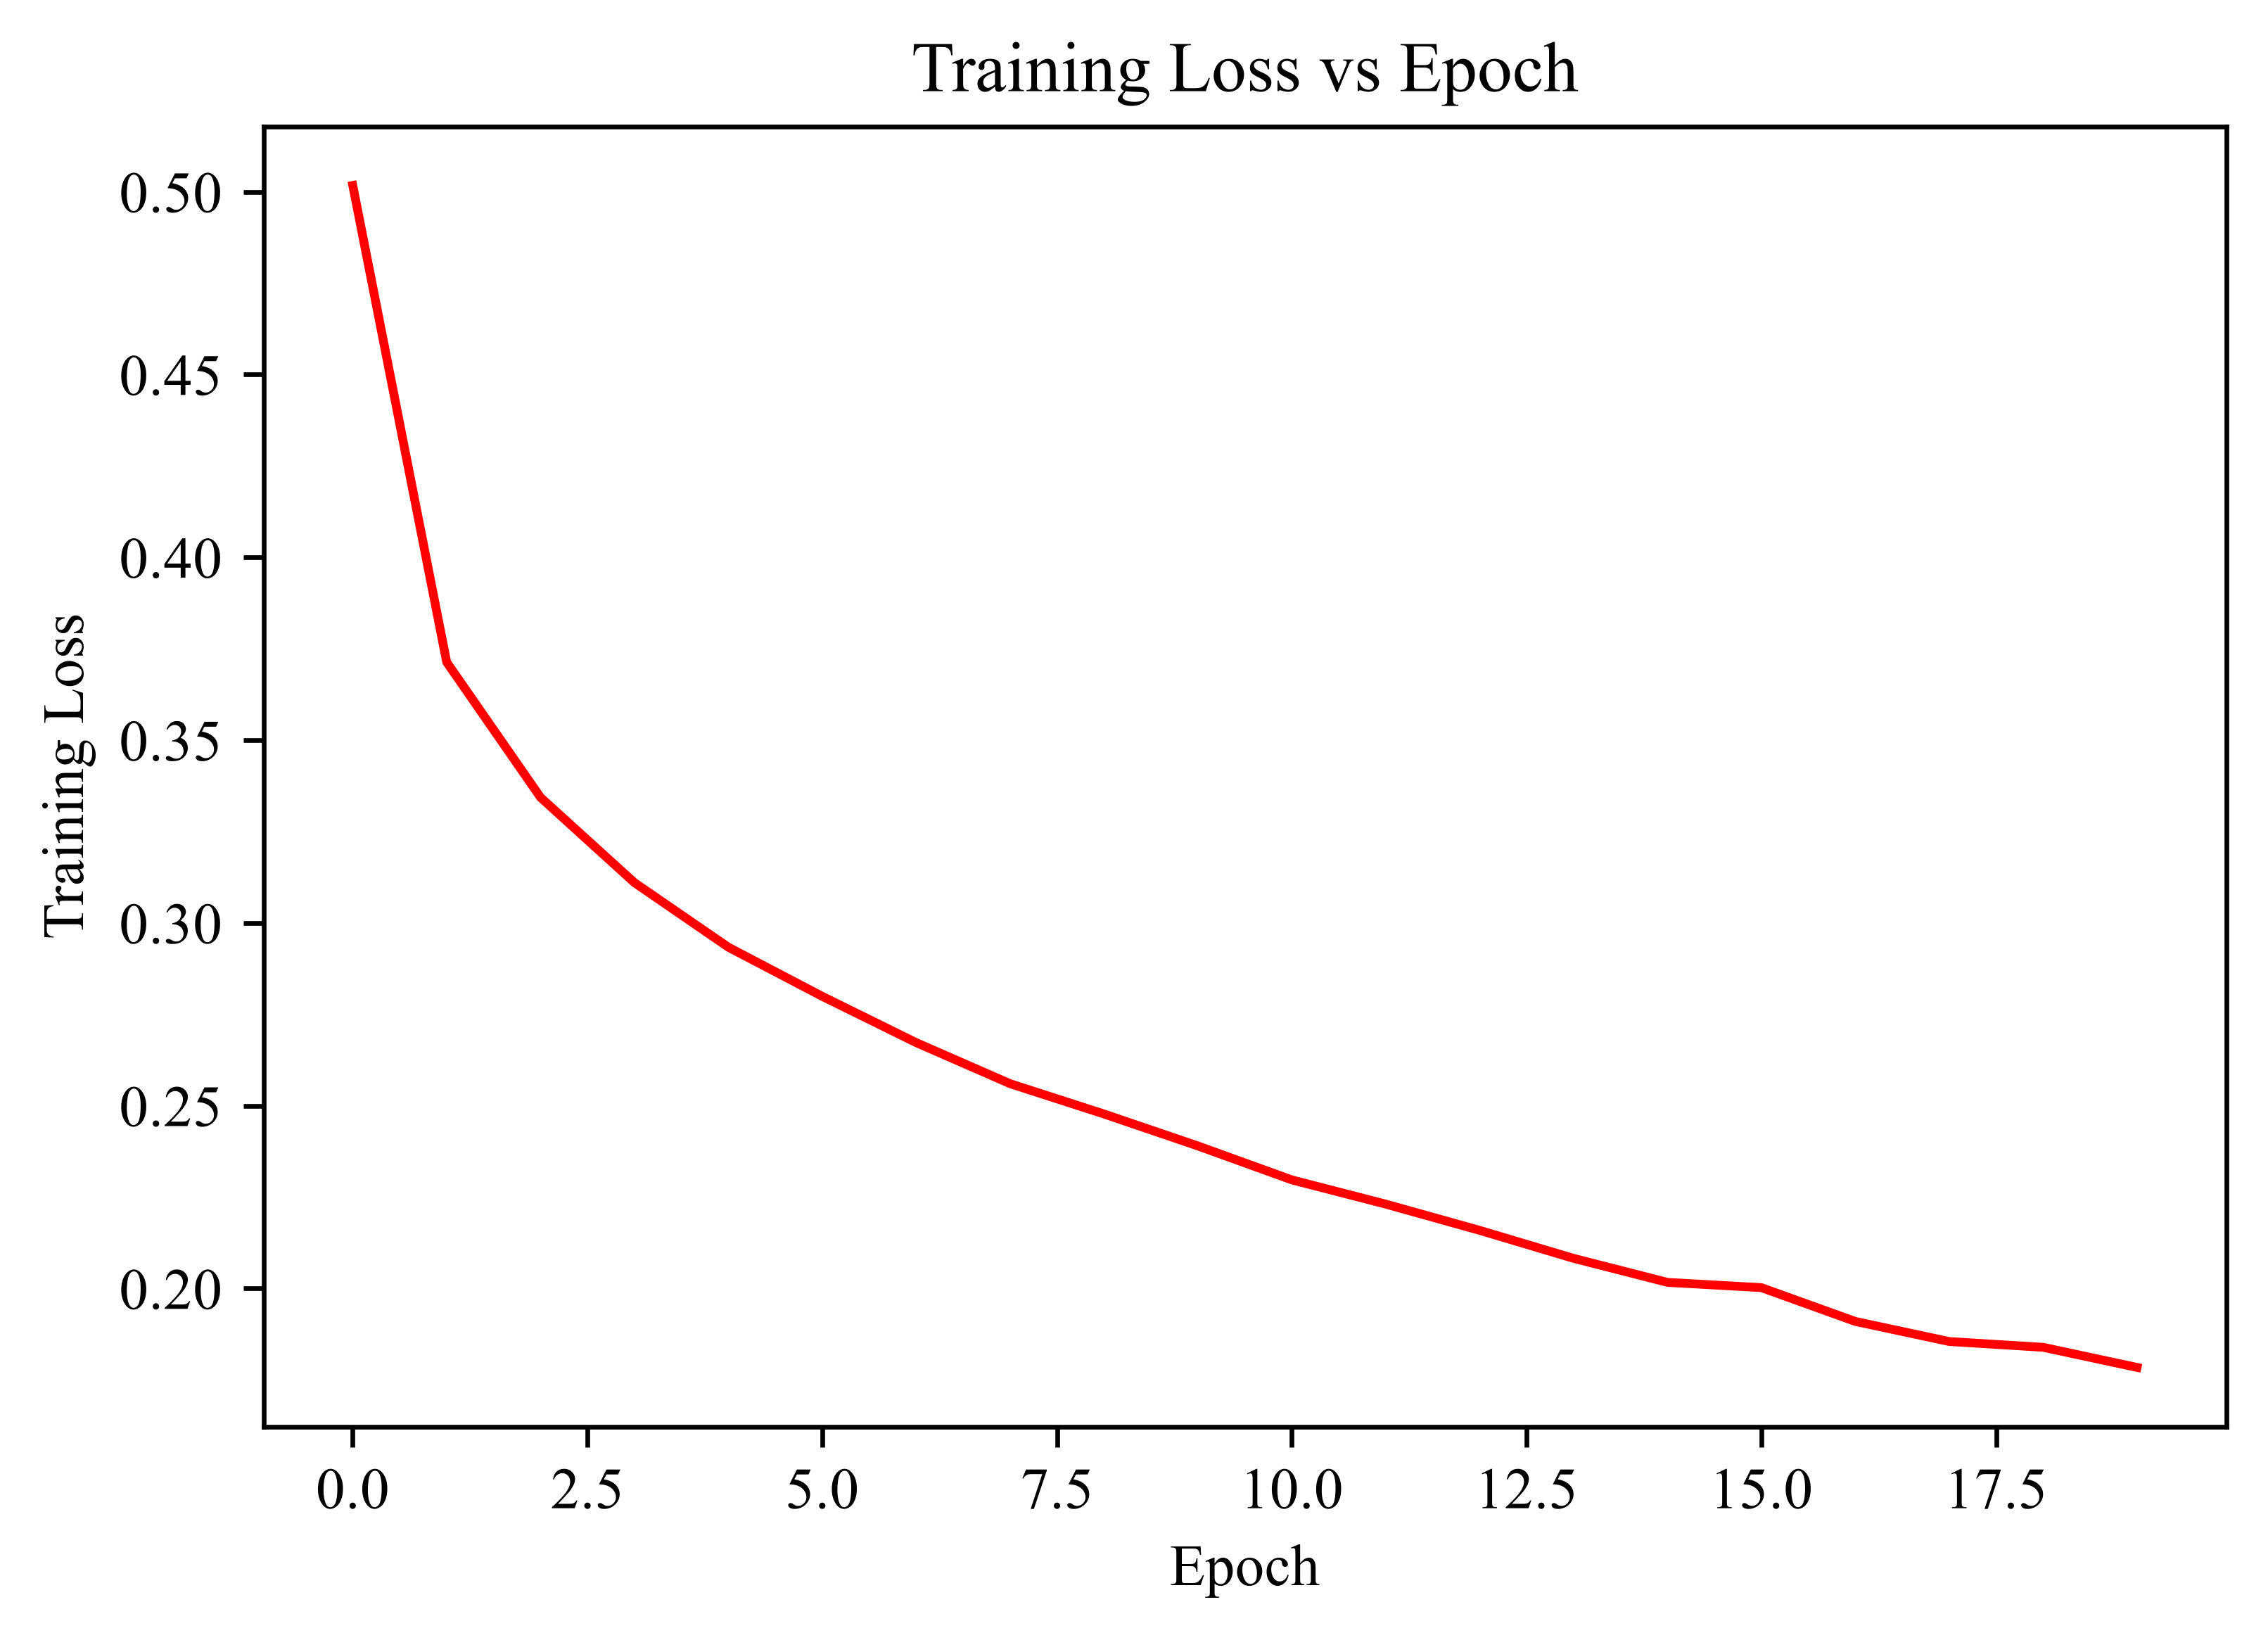

In [12]:
# training loss vs epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], color='red')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
save_plot("training_loss_vs_epoch")
plt.show()

# Inference: training loss decreases consistently which confirms the
# model is minimizing the categorical cross entropy loss during training.


saved validation_loss_vs_epoch.eps


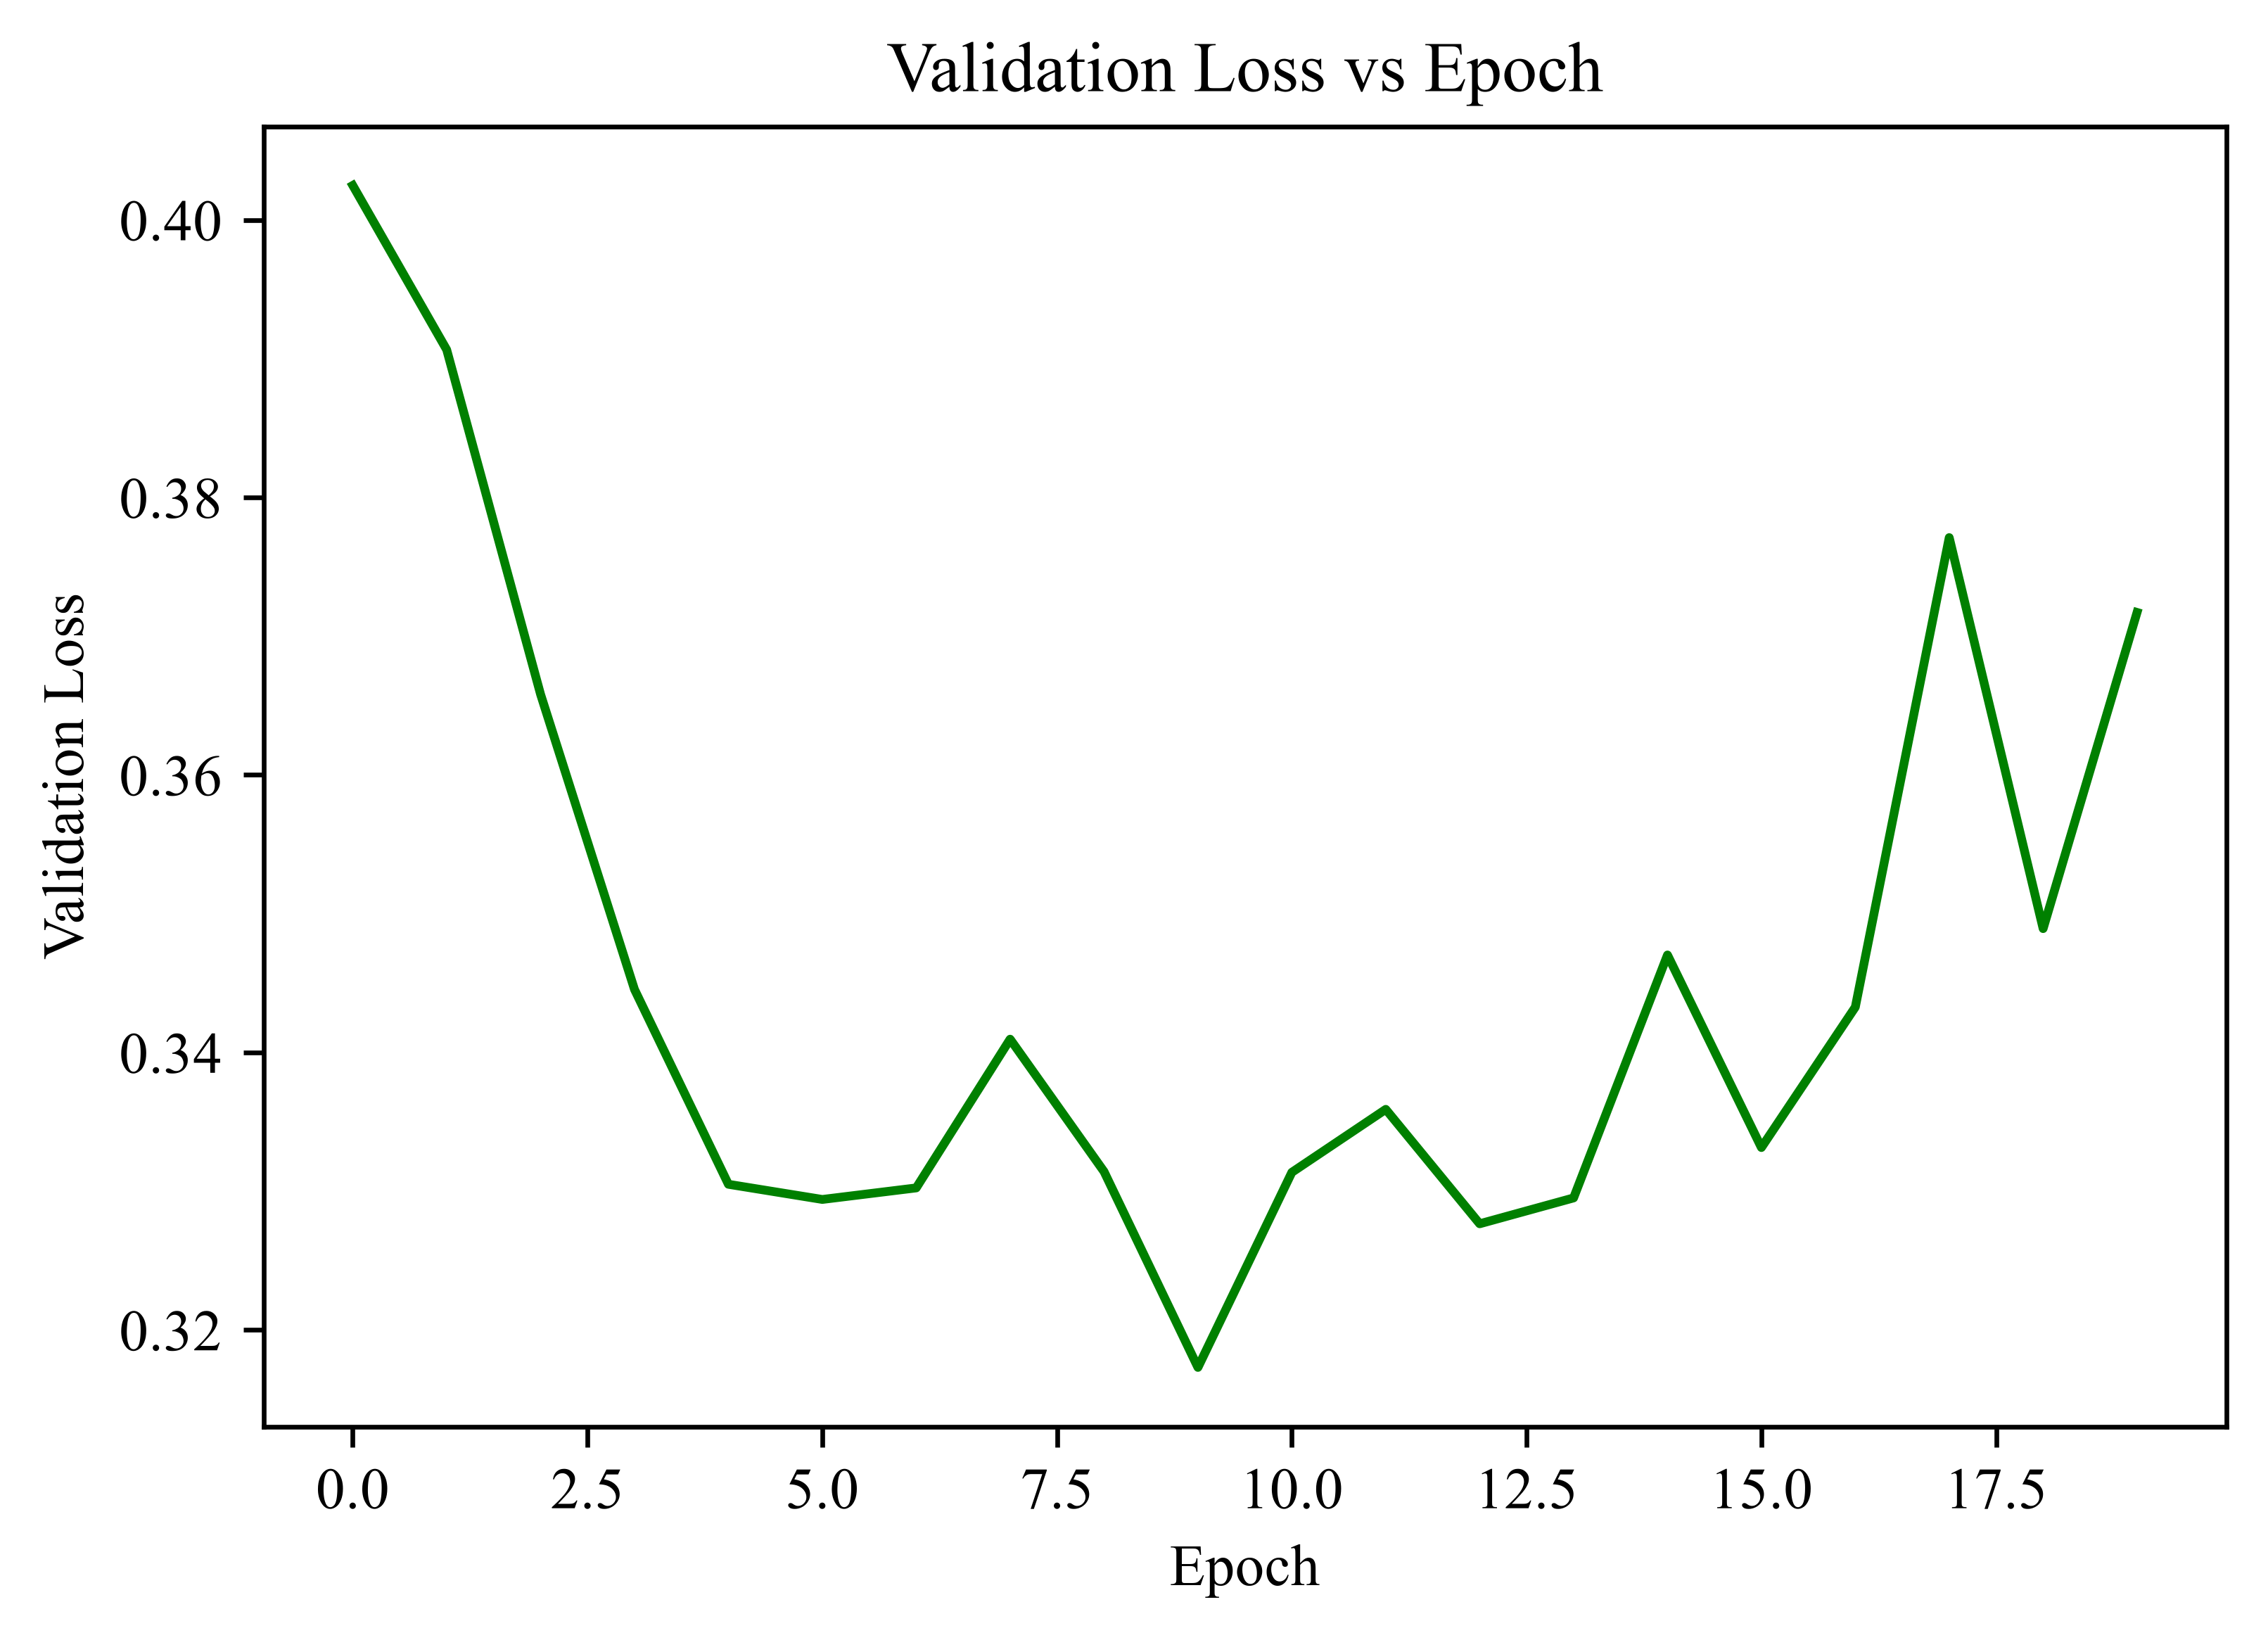

In [13]:
# validation loss vs epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], color='green')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
save_plot("validation_loss_vs_epoch")
plt.show()

# Inference: validation loss decreases initially but might slightly go up
# towards the end epochs, which could be an early sign of overfitting.


In [14]:
y_pred_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

baseline_acc = accuracy_score(y_true, y_pred)
baseline_prec = precision_score(y_true, y_pred, average='macro')
baseline_rec = recall_score(y_true, y_pred, average='macro')
baseline_f1 = f1_score(y_true, y_pred, average='macro')

print("Baseline Accuracy :", baseline_acc)
print("Baseline Precision:", baseline_prec)
print("Baseline Recall   :", baseline_rec)
print("Baseline F1-score :", baseline_f1)

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Baseline Accuracy : 0.876
Baseline Precision: 0.8818607445580062
Baseline Recall   : 0.876
Baseline F1-score : 0.8766535858740732

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.86      0.76      0.81      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.87      0.68      0.76      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.77      0.82      0.79      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.62      0.75      0.68      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.96      0.97      0.97      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



saved confusion_matrix_baseline.eps


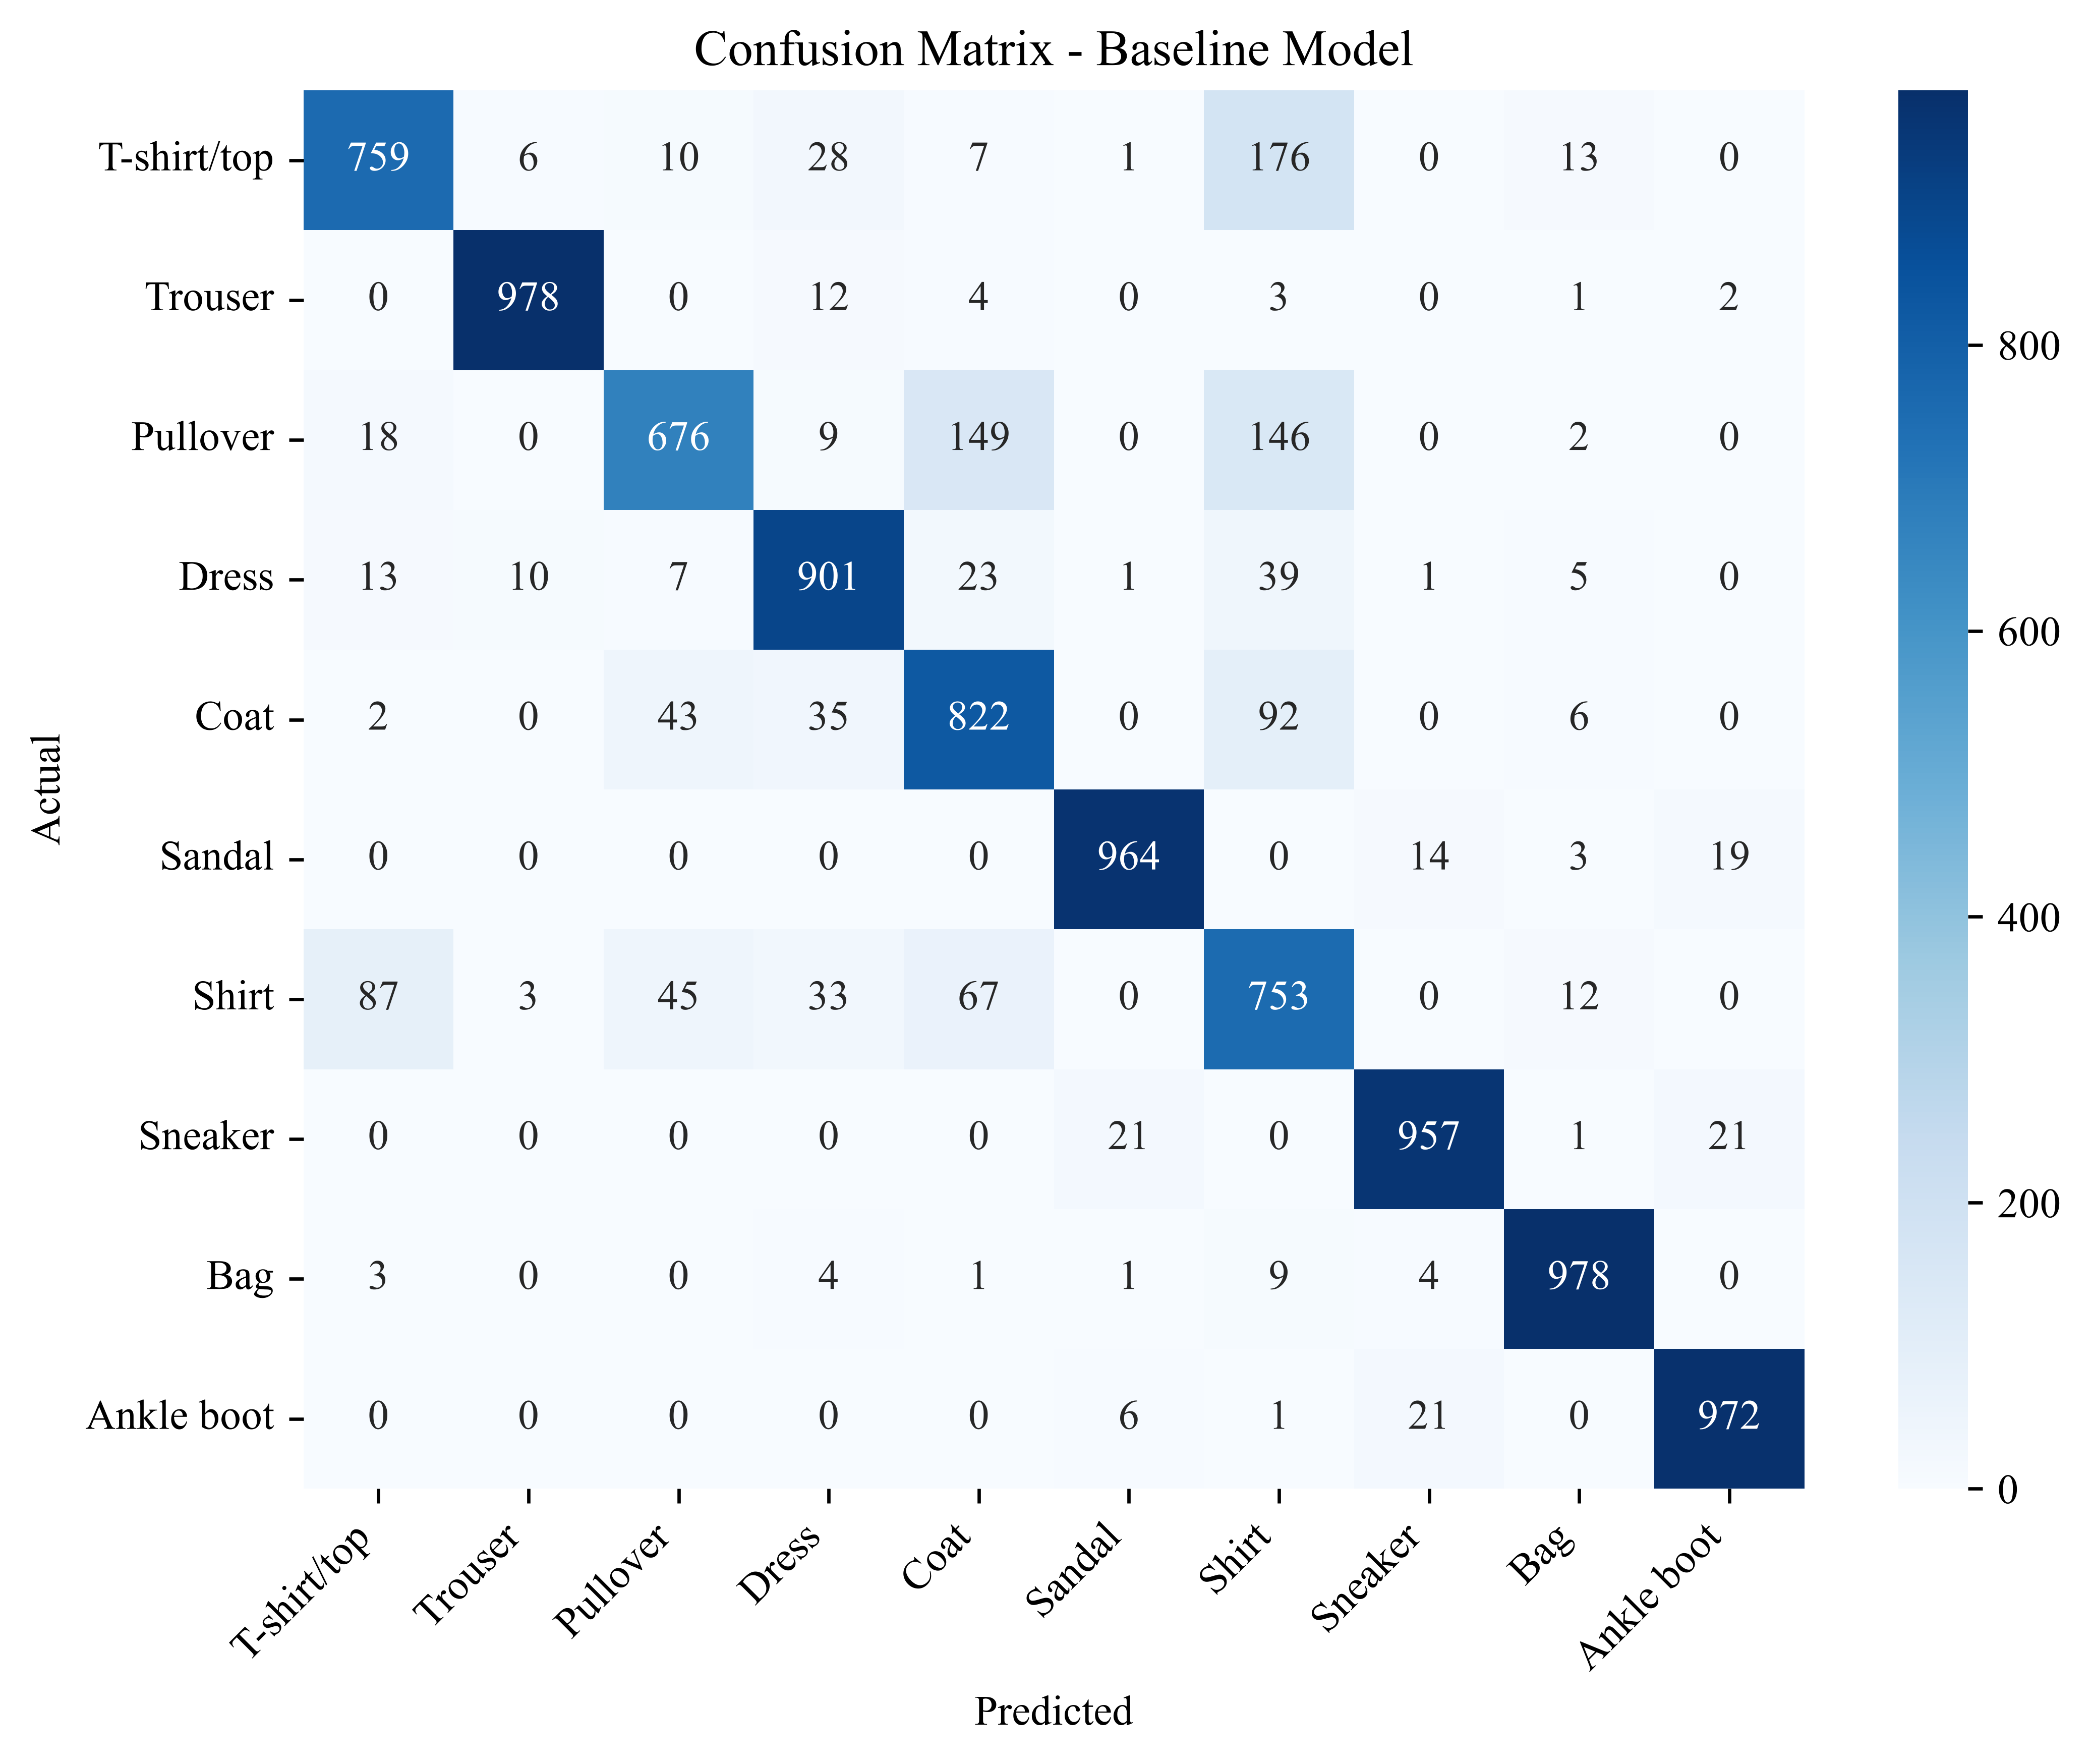

In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
save_plot("confusion_matrix_baseline")
plt.show()

# Inference: most predictions lie on the diagonal meaning the model classifies
# correctly most of the time, but some confusion exists between similar classes
# like shirt, pullover and coat since they look visually similar.



In [16]:
# function to build model dynamically based on hyperparameters
# this is needed for the SciKeras wrapper
def build_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                 optimizer_name='adam', activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Dense(hidden_neurons, activation=activation, input_shape=(784,)))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # adding remaining hidden layers
    for _ in range(hidden_layers - 1):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    # picking the optimizer based on the string passed in
    if optimizer_name == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [17]:
# using only a subset of the training data for the search since running
# the full search on all 60000 images would take way too long on a normal laptop
# (note: this is the same reason mentioned in the report - hyperparameters
# found on this subset may not be exactly optimal for the full dataset,
# but it keeps the search feasible)
X_search = X_train[:12000]
y_search = y_train[:12000]

keras_clf = KerasClassifier(model=build_model, verbose=0)

# full search space as given in the lab manual
param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    verbose=1,
    random_state=42
)

random_search_result = random_search.fit(X_search, y_search)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


c:\Users\Kishore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Kishore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Kishore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first

KeyboardInterrupt: 

In [ ]:
print("Best Cross-validation Accuracy:", random_search_result.best_score_)
print("Best Hyperparameters:", random_search_result.best_params_)


Best Cross-validation Accuracy: 0.8659166666666666
Best Hyperparameters: {'model__optimizer_name': 'adam', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 2, 'model__dropout_rate': 0.0, 'model__activation': 'sigmoid', 'epochs': 30, 'batch_size': 32}


saved hyperparameter_search_results.eps


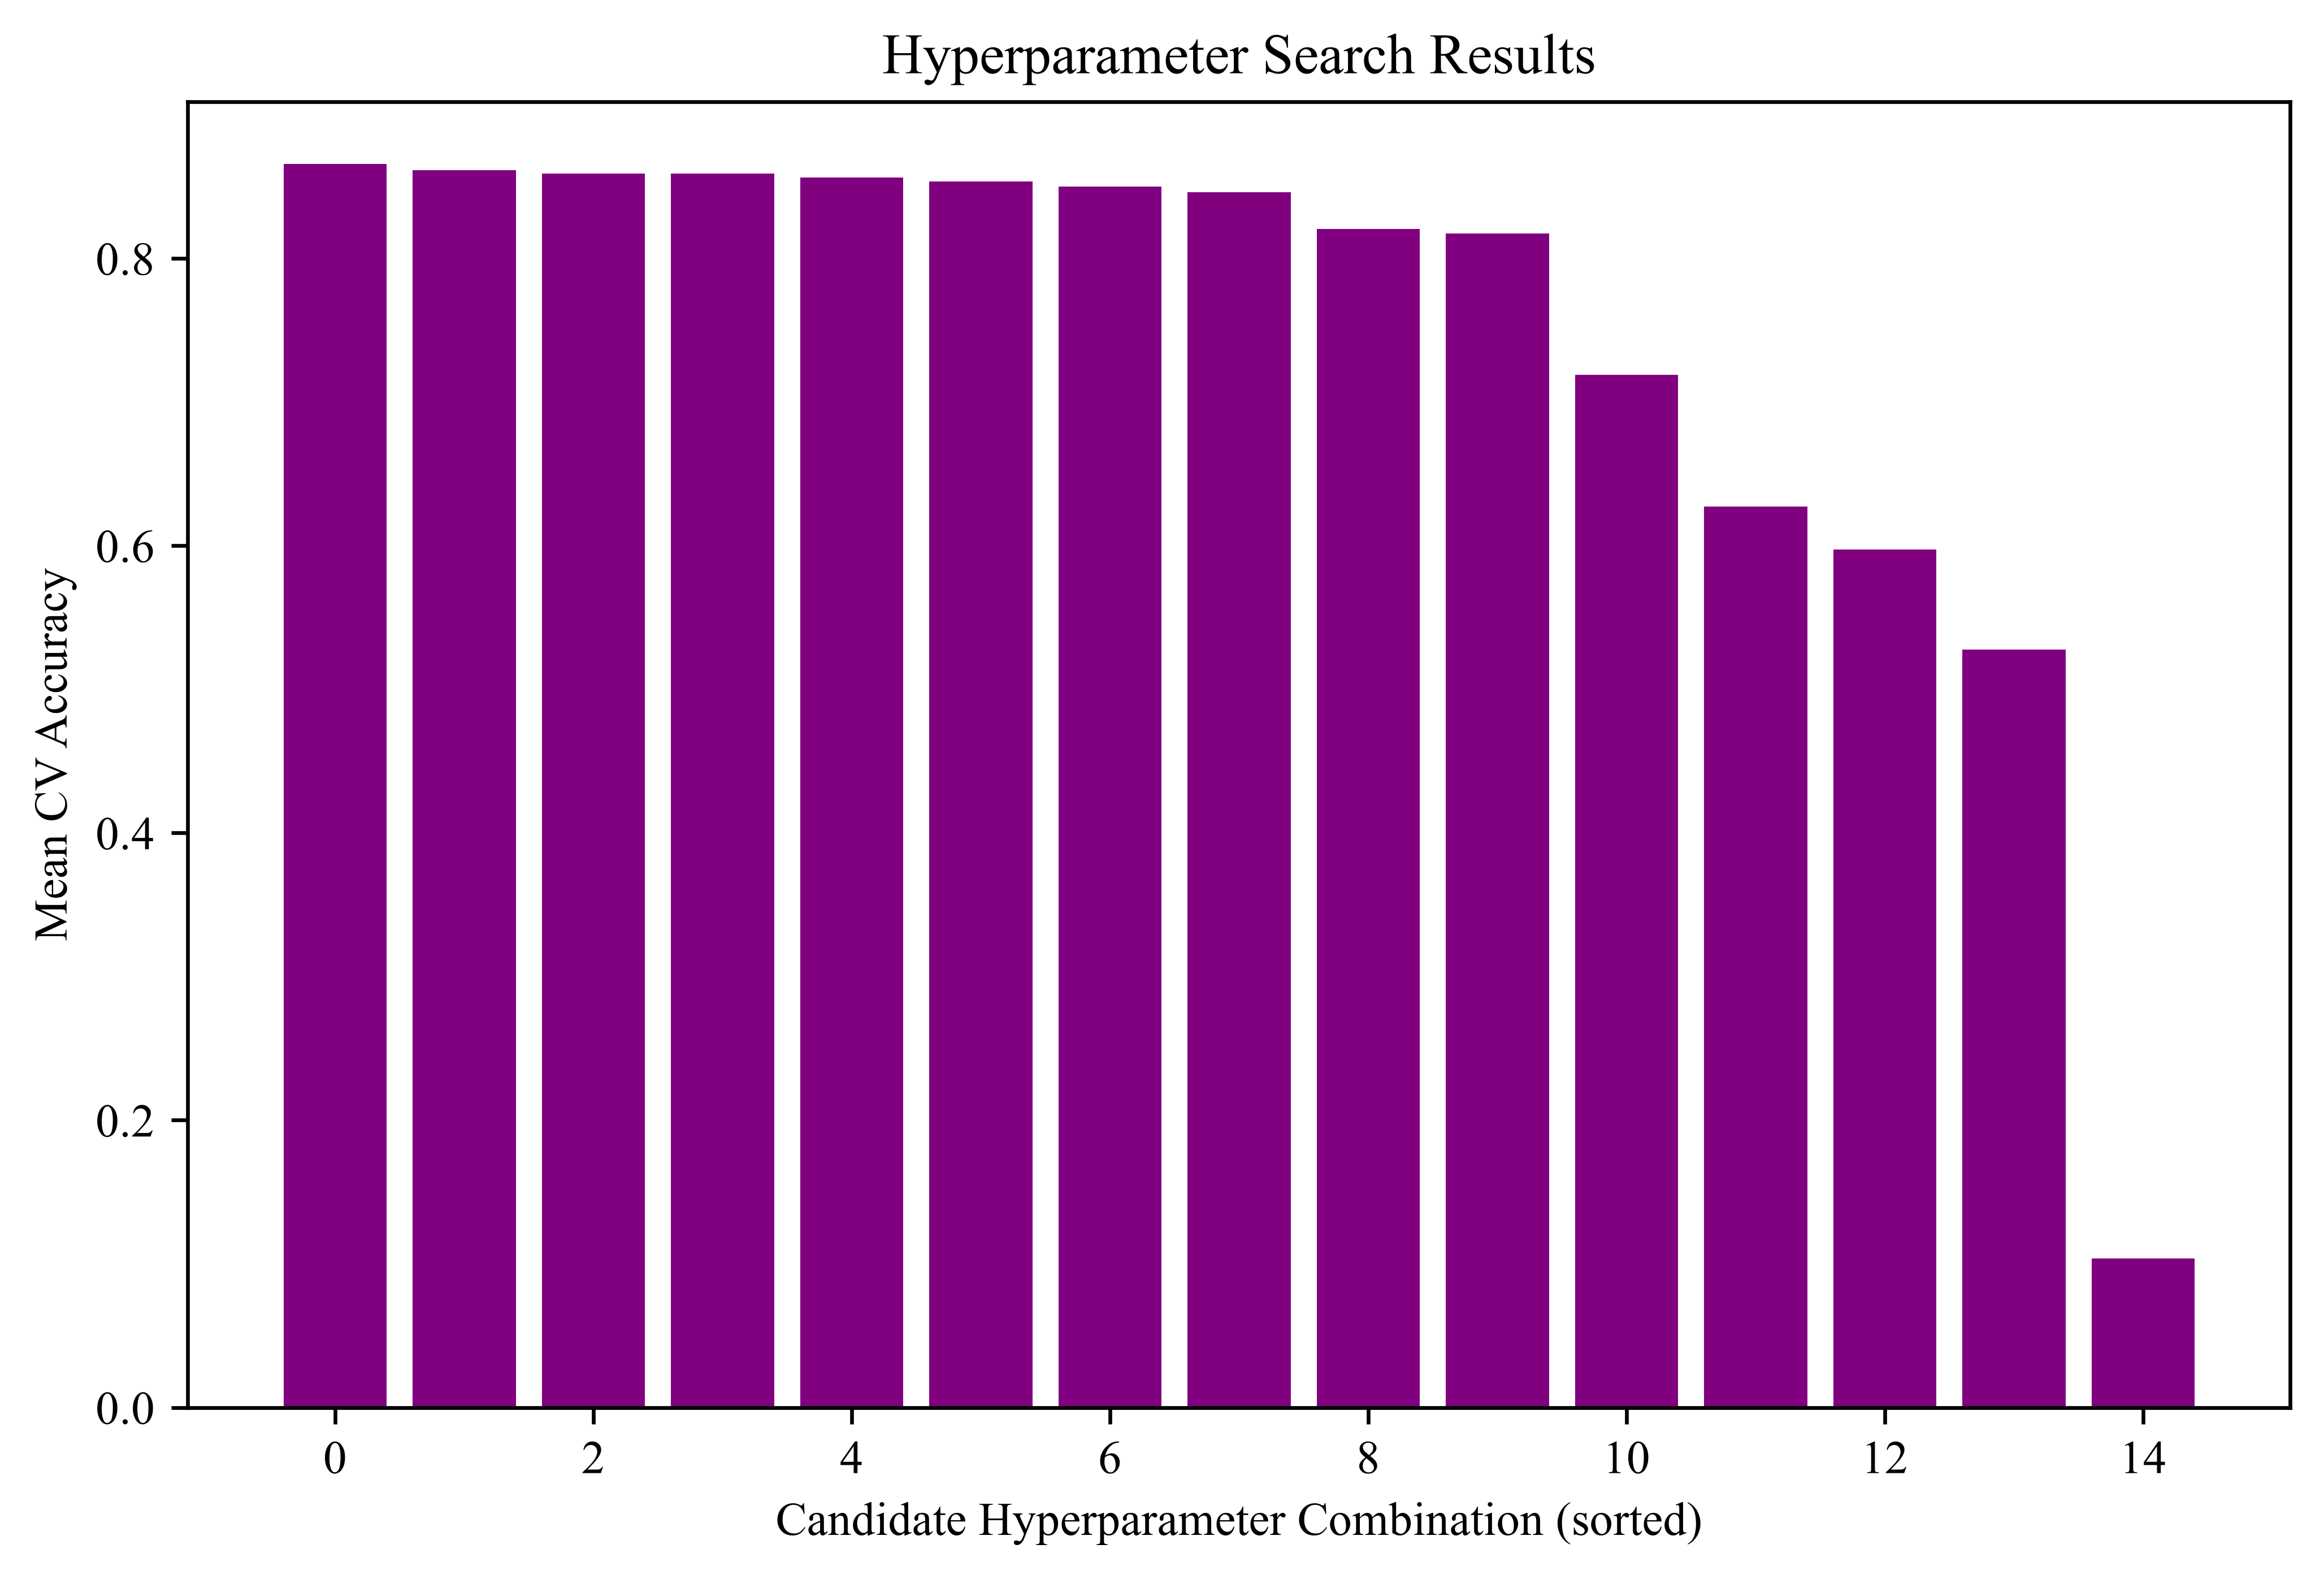

In [ ]:
# plotting the hyperparameter search results (mean test score for each candidate tried)
results_df = pd.DataFrame(random_search_result.cv_results_)
results_df_sorted = results_df.sort_values('mean_test_score', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(range(len(results_df_sorted)), results_df_sorted['mean_test_score'], color='purple')
plt.xlabel("Candidate Hyperparameter Combination (sorted)")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results")
save_plot("hyperparameter_search_results")
plt.show()

# Inference: some hyperparameter combinations perform clearly better than others,
# the best combination(s) are the ones with the tallest bars on the left.


In [ ]:
best_params = random_search_result.best_params_

optimized_model = build_model(
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    optimizer_name=best_params['model__optimizer_name'],   # add this line
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate']
)

start_time = time.time()

optimized_history = optimized_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)

optimized_train_time = time.time() - start_time
print("Optimized model training time (sec):", optimized_train_time)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8028 - loss: 0.5521 - val_accuracy: 0.8337 - val_loss: 0.4472
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8599 - loss: 0.3844 - val_accuracy: 0.8640 - val_loss: 0.3681
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8742 - loss: 0.3467 - val_accuracy: 0.8548 - val_loss: 0.3881
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8812 - loss: 0.3209 - val_accuracy: 0.8772 - val_loss: 0.3293
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8898 - loss: 0.2976 - val_accuracy: 0.8742 - val_loss: 0.3386
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8961 - loss: 0.2810 - val_accuracy: 0.8878 - val_loss: 0.3061
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9001 - loss: 0.2669 - val_accuracy: 0.8853 - val_loss: 0.3194
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9044 - loss: 0.2545 - 

In [ ]:
# evaluating the optimized model
opt_pred_prob = optimized_model.predict(X_test)
opt_pred = np.argmax(opt_pred_prob, axis=1)

optimized_acc = accuracy_score(y_true, opt_pred)
optimized_prec = precision_score(y_true, opt_pred, average='macro')
optimized_rec = recall_score(y_true, opt_pred, average='macro')
optimized_f1 = f1_score(y_true, opt_pred, average='macro')

print("Optimized Accuracy :", optimized_acc)
print("Optimized Precision:", optimized_prec)
print("Optimized Recall   :", optimized_rec)
print("Optimized F1-score :", optimized_f1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Optimized Accuracy : 0.892
Optimized Precision: 0.8930721520940825
Optimized Recall   : 0.892
Optimized F1-score : 0.8916684833060895


saved best_model_accuracy_comparison.eps


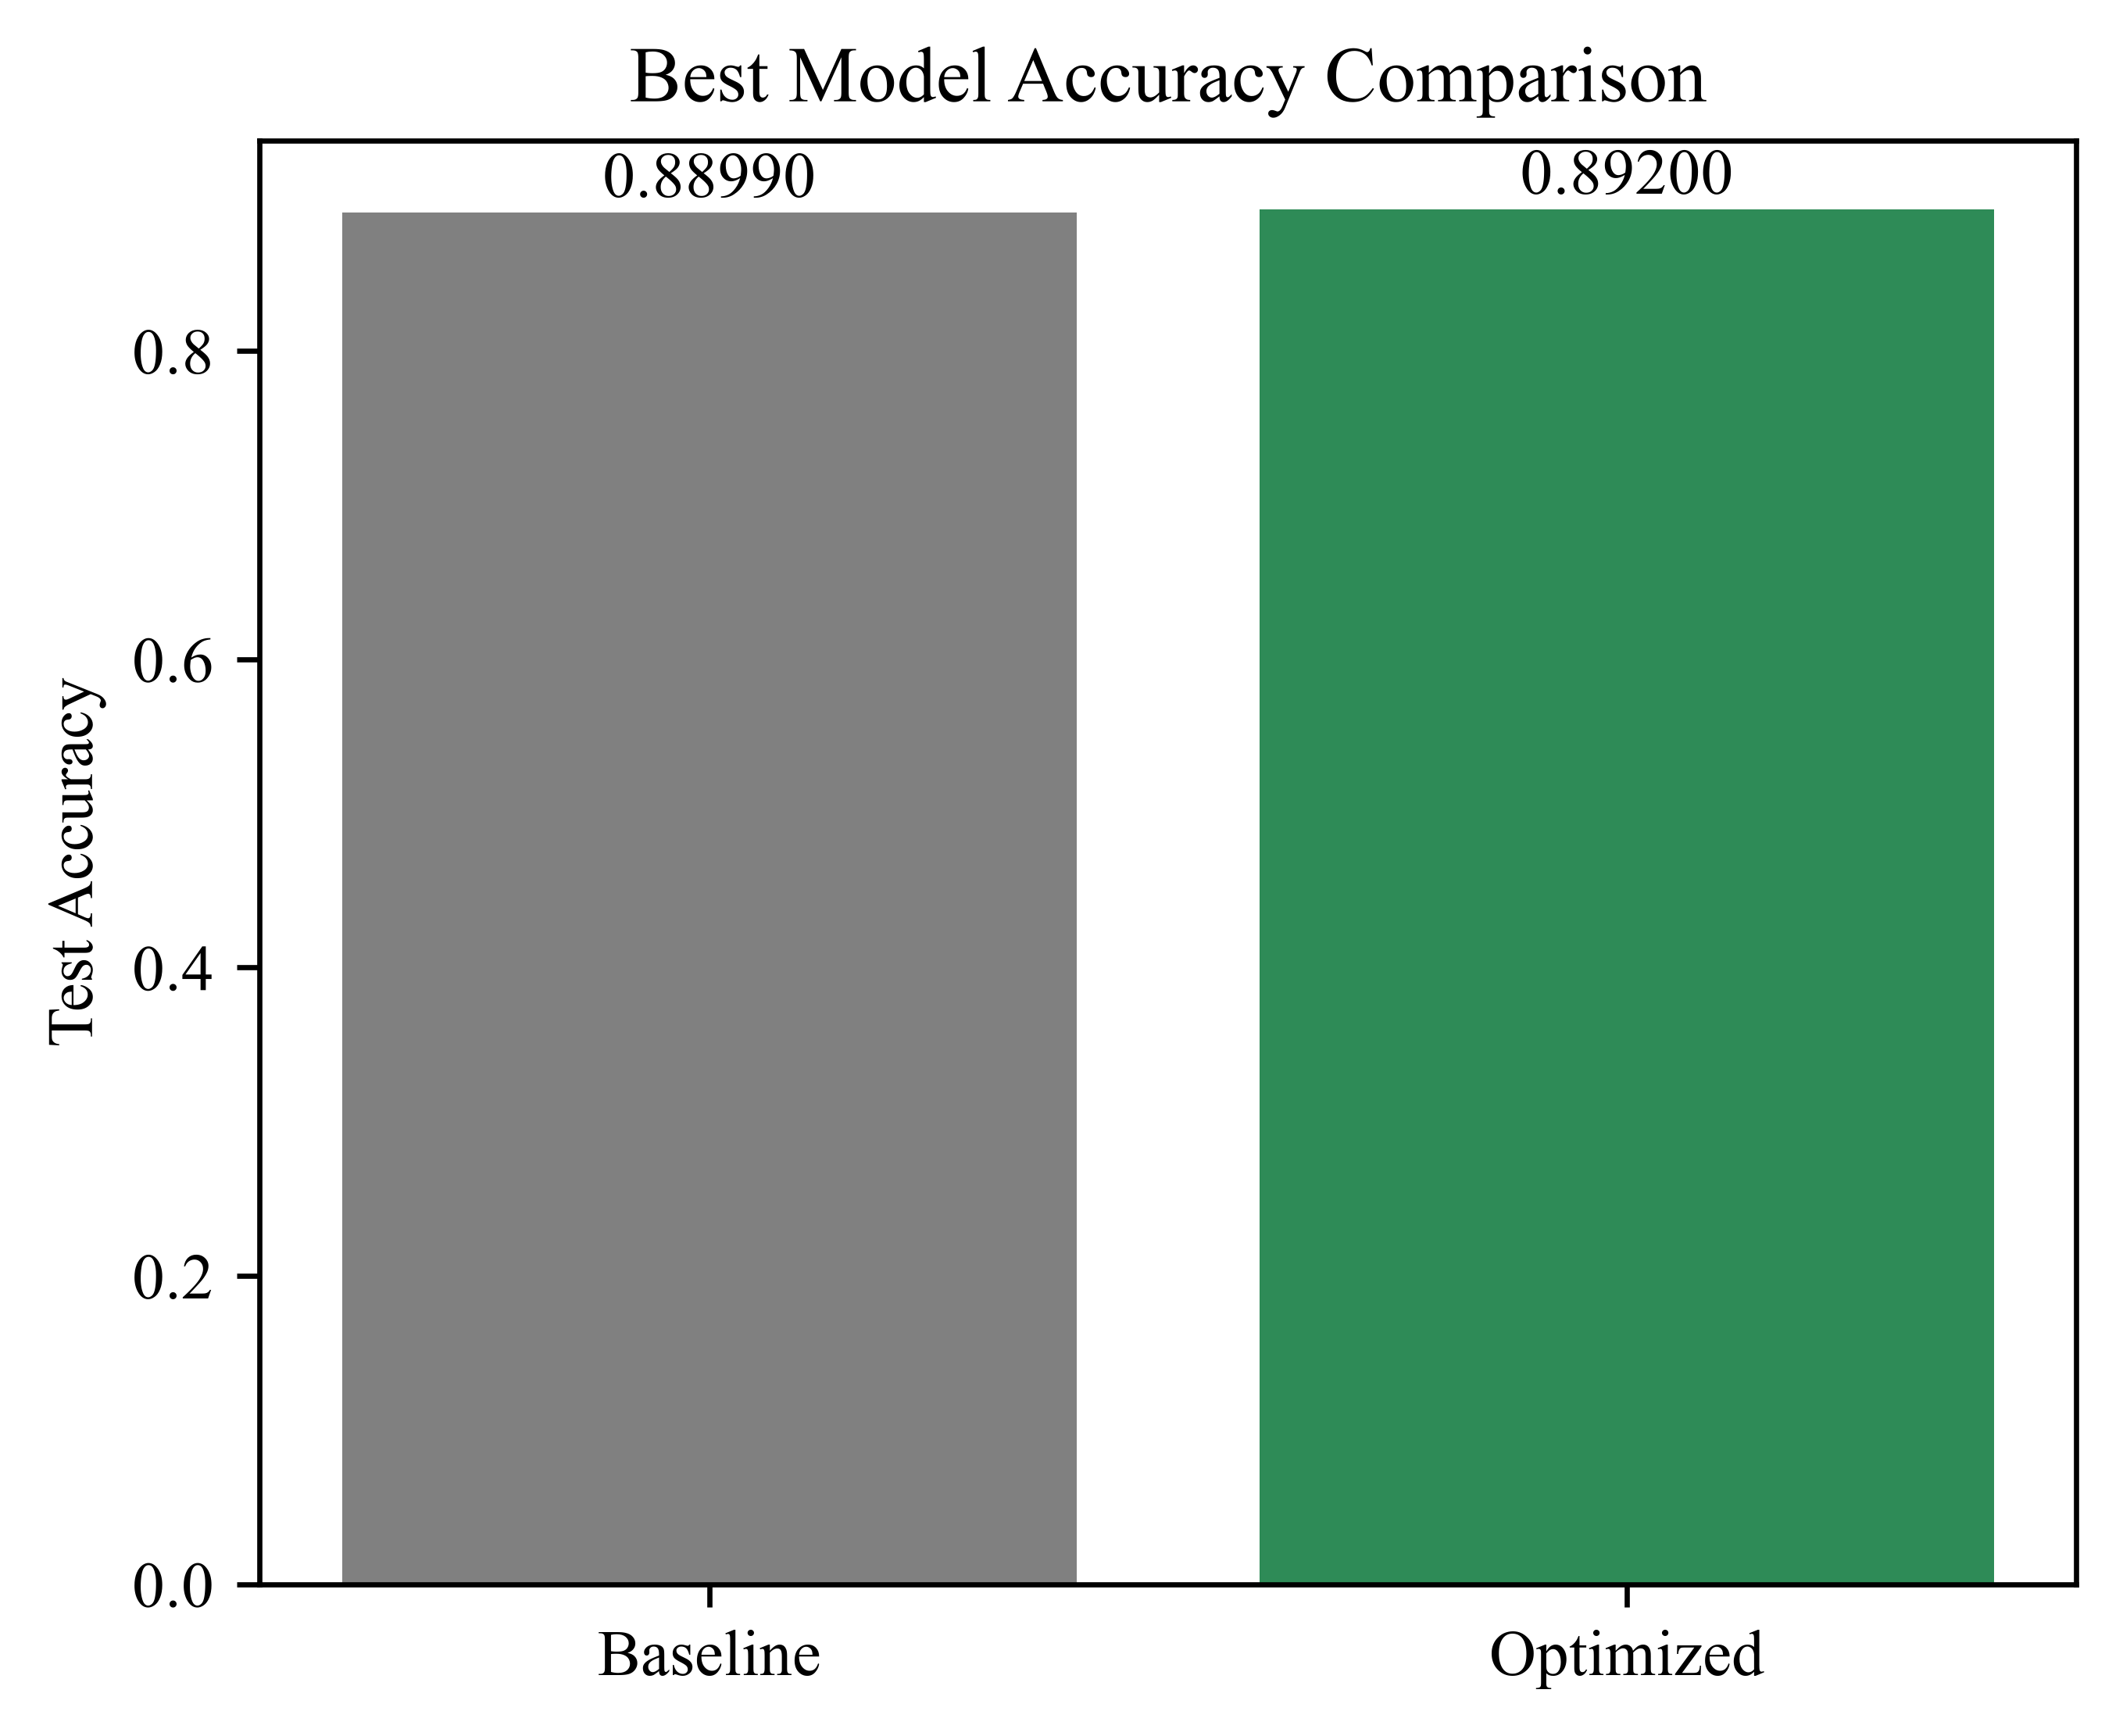

In [ ]:
# best model accuracy comparison plot
labels = ['Baseline', 'Optimized']
accuracies = [baseline_acc, optimized_acc]

plt.figure(figsize=(5, 4))
plt.bar(labels, accuracies, color=['gray', 'seagreen'])
plt.ylabel("Test Accuracy")
plt.title("Best Model Accuracy Comparison")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.5f}", ha='center')
save_plot("best_model_accuracy_comparison")
plt.show()

# Inference: the optimized model performs better (or at least comparable to)
# the baseline model, showing that hyperparameter tuning helps improve performance.


In [ ]:
# performance comparison table
comparison_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Training Time (sec)'],
    'Baseline': [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_train_time],
    'Optimized': [optimized_acc, optimized_prec, optimized_rec, optimized_f1, optimized_train_time]
})

comparison_table

,Metric,Baseline,Optimized
0,Accuracy,0.889900,0.892000
1,Precision,0.892864,0.893072
2,Recall,0.889900,0.892000
3,F1-score,0.890348,0.891668
4,Training Time (sec),52.576723,117.350968
